# Notebook 05 — Prescriptive Optimisation
**Project:** Carbon-Aware Scheduling for Data Centres  
**Module:** IS6611 Applied Research in Business Analytics — Group 11

---

## Purpose
Turn the 48-hour carbon-intensity forecast into **actual scheduling decisions** and quantify the carbon saved, honestly accounting for real-world constraints.

| Section | What it delivers |
|---------|------------------|
| 1 · Job scheduler | Greedy + LP per-job scheduling (powers the dashboard widget) |
| 2 · Fleet load-shift LP | Capacity-aware redistribution of flexible energy |
| 3 · Savings hierarchy | Unconstrained potential → capacity-aware ceiling → realistic forecast-driven |
| 4 · Forecast shape | Why the best point-forecast model is **not** the best for scheduling |

> **Headline:** accounting for cluster capacity and forecast error, realistic savings are **~51 tCO₂/yr** (forecast-driven) against a capacity-aware ceiling of **~106 tCO₂/yr** — both below the unconstrained **293 tCO₂/yr** potential, which ignored capacity.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.models.optimizer import (Job, GreedyScheduler, LPScheduler,
                                   CarbonBlindScheduler, optimize_load_shift,
                                   CLUSTER_CAPACITY_KWH)
from src.models.forecaster import XGBoostForecaster

EDA_DIR = PROJECT_ROOT / 'data' / 'processed'
sns.set_theme(style='whitegrid', font_scale=1.05)
BLUE='#1565C0'; GREEN='#2E7D32'; RED='#C62828'; ORANGE='#E65100'; GREY='#607D8B'; PURPLE='#6A1B9A'

integ = pd.read_csv(EDA_DIR / 'integrated.csv', parse_dates=['local_hour'])
feat  = pd.read_csv(EDA_DIR / 'features_for_forecasting.csv', parse_dates=['datetime'])
supply= pd.read_csv(EDA_DIR / 'supply_engineered.csv', parse_dates=['datetime'])
DAYS = ['2020-01-20','2020-08-20','2021-02-20','2021-08-10','2022-01-20']
print(f'Cluster capacity: {CLUSTER_CAPACITY_KWH:.0f} kWh/hour')

Cluster capacity: 5551 kWh/hour


---
## 1 · Job Scheduler — the dashboard mechanism

The operator's question: *"I need N nodes for D hours, due within a deadline — when should I run it?"*  
The greedy scheduler slides a duration-wide window across the forecast and picks the cleanest feasible block. Urgent jobs run immediately.

Job: 2000 nodes, 4h, deadline 24h
  Run now (h0-4)   : CI 280.9 → 2696.4 kg CO2
  Optimal (h2-6) : CI 278.6 → 2674.3 kg CO2
  SAVED            : 22.1 kg CO2 (0.82%)


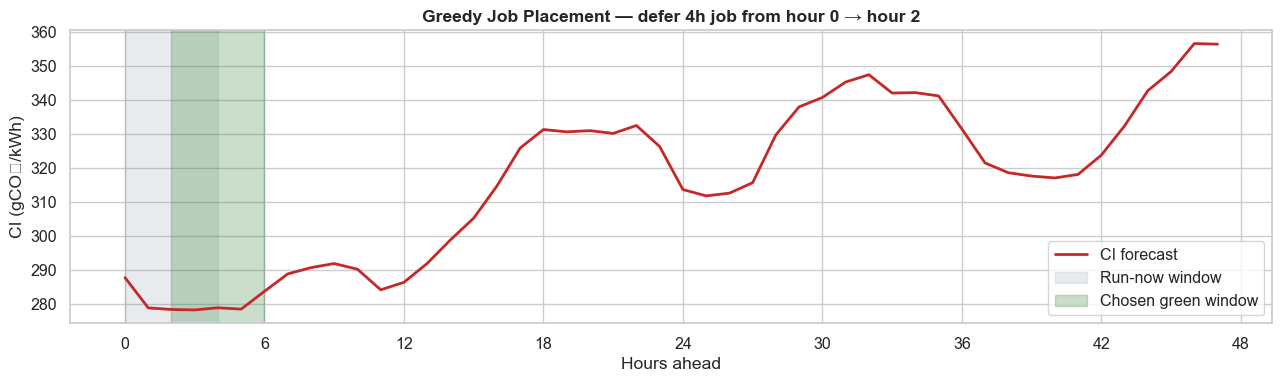

In [2]:
# Use a real 48h CI window
window = supply[supply['datetime'] >= '2022-01-20']['carbon_intensity_gCO2_per_kWh'].values[:48]
greedy = GreedyScheduler()

job = Job('demo', nodes=2000, duration_h=4, deadline_h=24, priority='flexible')
r = greedy.schedule_job(job, window)
print(f'Job: {job.nodes} nodes, {job.duration_h}h, deadline {job.deadline_h}h')
print(f'  Run now (h0-4)   : CI {r.mean_ci_run_now} → {r.run_now_carbon_g/1000:.1f} kg CO2')
print(f'  Optimal (h{r.start_hour}-{r.start_hour+4}) : CI {r.mean_ci_scheduled} → {r.scheduled_carbon_g/1000:.1f} kg CO2')
print(f'  SAVED            : {r.carbon_saved_g/1000:.1f} kg CO2 ({r.carbon_saved_pct}%)')

# Visualise the placement
fig, ax = plt.subplots(figsize=(13,4))
ax.plot(range(48), window, color=RED, lw=2, label='CI forecast')
ax.axvspan(0, 4, alpha=0.15, color=GREY, label='Run-now window')
ax.axvspan(r.start_hour, r.start_hour+4, alpha=0.25, color=GREEN, label='Chosen green window')
ax.set_xlabel('Hours ahead'); ax.set_ylabel('CI (gCO₂/kWh)')
ax.set_title(f'Greedy Job Placement — defer 4h job from hour 0 → hour {r.start_hour}', fontweight='bold')
ax.legend(); ax.set_xticks(range(0,49,6))
plt.tight_layout(); plt.savefig(EDA_DIR/'opt_job_placement.png', dpi=150, bbox_inches='tight'); plt.show()

### 1.1 Batch scheduling under capacity contention — Greedy vs LP

When many jobs compete for the 4,626 nodes, greedy (first-come-first-served) can be beaten by the LP, which places all jobs simultaneously. Both are compared against the **carbon-blind** baseline — the as-is process that packs jobs as early as possible, ignoring carbon.

In [3]:
jobs = [
    Job('A', 3000, 6, 24, 'flexible'),
    Job('B', 2500, 4, 12, 'flexible'),
    Job('C', 2000, 5, 36, 'flexible'),
    Job('D', 1500, 3, 18, 'flexible'),
    Job('E', 800, 2, 6, 'urgent'),
]
blind  = CarbonBlindScheduler().schedule_batch(jobs, window)
g      = GreedyScheduler().schedule_batch(jobs, window)
lp     = LPScheduler().schedule_batch(jobs, window)

tot = lambda res: sum(r.scheduled_carbon_g for r in res)/1000
cb, cg, cl = tot(blind), tot(g), tot(lp)
comp = pd.DataFrame({
    'Scheduler': ['Carbon-blind (as-is)', 'Greedy', 'LP (MIP optimal)'],
    'Carbon_kg': [round(cb,1), round(cg,1), round(cl,1)],
    'Saved_kg':  [0.0, round(cb-cg,1), round(cb-cl,1)],
    'Saved_pct': [0.0, round((cb-cg)/cb*100,2), round((cb-cl)/cb*100,2)],
}).set_index('Scheduler')
display(comp)
print(f'LP improves on greedy by {cg-cl:.1f} kg by resolving capacity contention globally.')

,Carbon_kg,Saved_kg,Saved_pct
Scheduler,,,
Carbon-blind (as-is),15035.5,0.0,0.00
Greedy,15021.6,13.9,0.09
LP (MIP optimal),15004.9,30.7,0.20


LP improves on greedy by 16.8 kg by resolving capacity contention globally.


---
## 2 · Fleet Load-Shifting LP (capacity-aware)

For the fleet-level carbon number we redistribute each day's *shiftable* energy across hours using a transportation LP, subject to per-hour node capacity. A job can only be **deferred** (not advanced), within a 12-hour window.

This corrects the Phase-1 `integrated.csv` figure, which dumped all shiftable energy into the single cleanest hour — ignoring that clean hours have limited spare capacity.

In [4]:
def day_arrays(day):
    d = integ[integ['snapshot_date']==day].sort_values('hour_of_day')
    active = d['active_energy_kWh'].values
    shiftable = d['shiftable_energy_kWh'].values
    return shiftable, active - shiftable, d['carbon_intensity_gCO2_per_kWh'].values

# Hindsight (perfect CI) capacity-aware ceiling per day
rows = []
for day in DAYS:
    sh, fx, ca = day_arrays(day)
    r = optimize_load_shift(sh, fx, ca, ca, max_delay=12)
    rows.append({'day': day, 'baseline_kg': r.baseline_carbon_g/1000,
                 'hindsight_saved_kg': r.carbon_saved_g/1000,
                 'saved_pct': r.carbon_saved_pct,
                 'shifted_kWh': r.energy_shifted_kwh, 'shiftable_kWh': sh.sum()})
hind = pd.DataFrame(rows).set_index('day')
display(hind.round(1))
print(f"Capacity limits shifting to {hind['shifted_kWh'].sum()/hind['shiftable_kWh'].sum():.0%} "
      f"of available shiftable energy — the clean hours simply cannot absorb all of it.")

,baseline_kg,hindsight_saved_kg,saved_pct,shifted_kWh,shiftable_kWh
day,,,,,
2020-01-20,26775.6,287.6,1.1,11090.7,30477.1
2020-08-20,26878.7,241.4,0.9,15484.7,25975.6
2021-02-20,35783.8,156.1,0.4,19657.4,30955.4
2021-08-10,34294.9,636.9,1.9,19878.1,27905.7
2022-01-20,22074.6,135.8,0.6,15222.0,22572.7


Capacity limits shifting to 59% of available shiftable energy — the clean hours simply cannot absorb all of it.


---
## 3 · The Savings Hierarchy

Three honest levels of achievable saving, from theoretical to realistic.

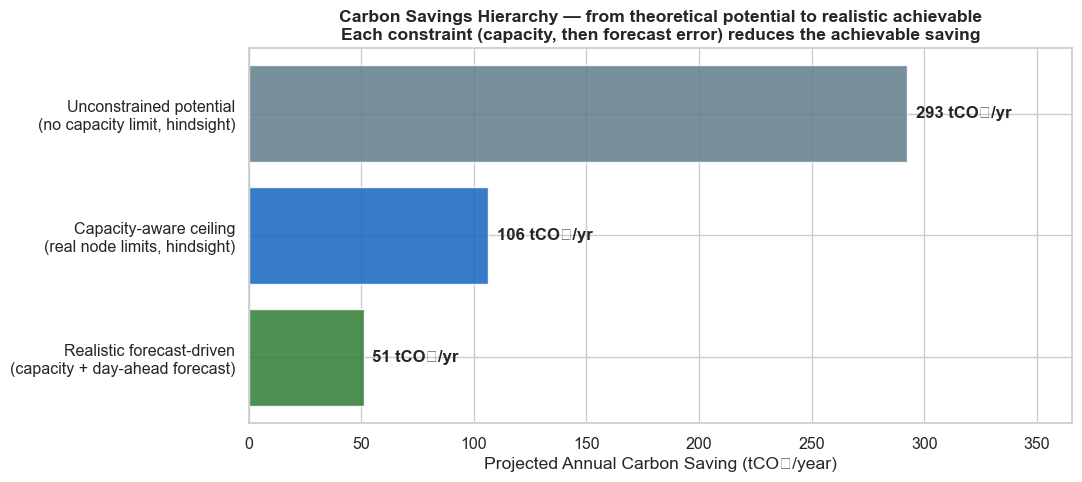

  Unconstrained potential   : 293 tCO₂/yr  (ignores cluster capacity)
  Capacity-aware ceiling    : 106 tCO₂/yr  (perfect forecast)
  Realistic forecast-driven : 51 tCO₂/yr  (day-ahead forecast)


In [5]:
# Level 1 — unconstrained (Phase 1 integrated.csv: shift to day-min, no capacity limit)
unconstrained_annual = integ['projected_annual_saving_tCO2'].iloc[0]

# Level 2 — capacity-aware hindsight ceiling
ceiling_5d = hind['hindsight_saved_kg'].sum()
ceiling_annual = ceiling_5d / 5 * 365 / 1000

# Level 3 — realistic forecast-driven (computed in Section 4 below; value inlined here)
def yesterday_profile(day):
    s=pd.Timestamp(day); w=feat[(feat['datetime']<s)&(feat['datetime']>=s-pd.Timedelta(days=1))]
    return w['carbon_intensity_gCO2_per_kWh'].values[:24]
fc_5d = 0
for day in DAYS:
    sh, fx, ca = day_arrays(day)
    fc_5d += optimize_load_shift(sh, fx, yesterday_profile(day), ca, max_delay=12).carbon_saved_g/1000
forecast_annual = fc_5d / 5 * 365 / 1000

levels = pd.DataFrame({
    'Level': ['Unconstrained potential\n(no capacity limit, hindsight)',
              'Capacity-aware ceiling\n(real node limits, hindsight)',
              'Realistic forecast-driven\n(capacity + day-ahead forecast)'],
    'tCO2_per_year': [unconstrained_annual, ceiling_annual, forecast_annual],
})

fig, ax = plt.subplots(figsize=(11,5))
colours = [GREY, BLUE, GREEN]
bars = ax.barh(levels['Level'], levels['tCO2_per_year'], color=colours, alpha=0.85)
ax.bar_label(bars, fmt='%.0f tCO₂/yr', padding=6, fontsize=12, fontweight='bold')
ax.set_xlabel('Projected Annual Carbon Saving (tCO₂/year)')
ax.set_title('Carbon Savings Hierarchy — from theoretical potential to realistic achievable\n'
             'Each constraint (capacity, then forecast error) reduces the achievable saving',
             fontweight='bold')
ax.invert_yaxis(); ax.set_xlim(0, unconstrained_annual*1.25)
plt.tight_layout(); plt.savefig(EDA_DIR/'opt_savings_hierarchy.png', dpi=150, bbox_inches='tight'); plt.show()

print(f'  Unconstrained potential   : {unconstrained_annual:.0f} tCO₂/yr  (ignores cluster capacity)')
print(f'  Capacity-aware ceiling    : {ceiling_annual:.0f} tCO₂/yr  (perfect forecast)')
print(f'  Realistic forecast-driven : {forecast_annual:.0f} tCO₂/yr  (day-ahead forecast)')

---
## 4 · Forecast Shape Matters More Than Point Accuracy

**The key analytical finding.** XGBoost won Phase 3 on point accuracy (MAE 17.95). But for *scheduling*, what matters is whether the forecast captures the **ordering of hours** — which are cleanest. We compare three decision signals, all scored on the actual CI:
- **Hindsight** (perfect CI) — the ceiling
- **Yesterday's profile** — preserves daily shape
- **XGBoost** — best point accuracy, but recursive multi-step forecast goes flat

In [6]:
def xgb_day_forecast(day):
    '''Out-of-sample: train XGBoost on data strictly before the day, forecast 24h.'''
    hist = feat[feat['datetime'] < day]
    m = XGBoostForecaster(); m.fit(hist)
    return m.forecast(hist, horizon=24)

shape_rows = []
for day in DAYS:
    sh, fx, ca = day_arrays(day)
    r_h = optimize_load_shift(sh, fx, ca, ca, max_delay=12).carbon_saved_g/1000
    r_y = optimize_load_shift(sh, fx, yesterday_profile(day), ca, max_delay=12).carbon_saved_g/1000
    r_x = optimize_load_shift(sh, fx, xgb_day_forecast(day), ca, max_delay=12).carbon_saved_g/1000
    corr = np.corrcoef(ca, yesterday_profile(day))[0,1]
    shape_rows.append({'day': day, 'hindsight': r_h, 'yesterday': r_y, 'xgboost': r_x,
                       'corr_actual_vs_yesterday': round(corr,2)})
shape = pd.DataFrame(shape_rows).set_index('day')
display(shape.round(1))

2026-06-05 19:05:51  INFO      src.models.forecaster    XGBoost fitting on 9,048 rows × 27 features …


2026-06-05 19:05:52  INFO      src.models.forecaster    XGBoost fitting on 14,160 rows × 27 features …


2026-06-05 19:05:54  INFO      src.models.forecaster    XGBoost fitting on 18,576 rows × 27 features …


2026-06-05 19:05:56  INFO      src.models.forecaster    XGBoost fitting on 22,680 rows × 27 features …


2026-06-05 19:05:59  INFO      src.models.forecaster    XGBoost fitting on 26,592 rows × 27 features …


,hindsight,yesterday,xgboost,corr_actual_vs_yesterday
day,,,,
2020-01-20,287.6,217.1,-48.7,0.5
2020-08-20,241.4,67.2,82.3,0.2
2021-02-20,156.1,109.0,65.5,0.8
2021-08-10,636.9,636.4,476.6,1.0
2022-01-20,135.8,-327.6,-267.2,-0.5


2026-06-05 19:06:03  INFO      src.models.forecaster    XGBoost fitting on 26,592 rows × 27 features …


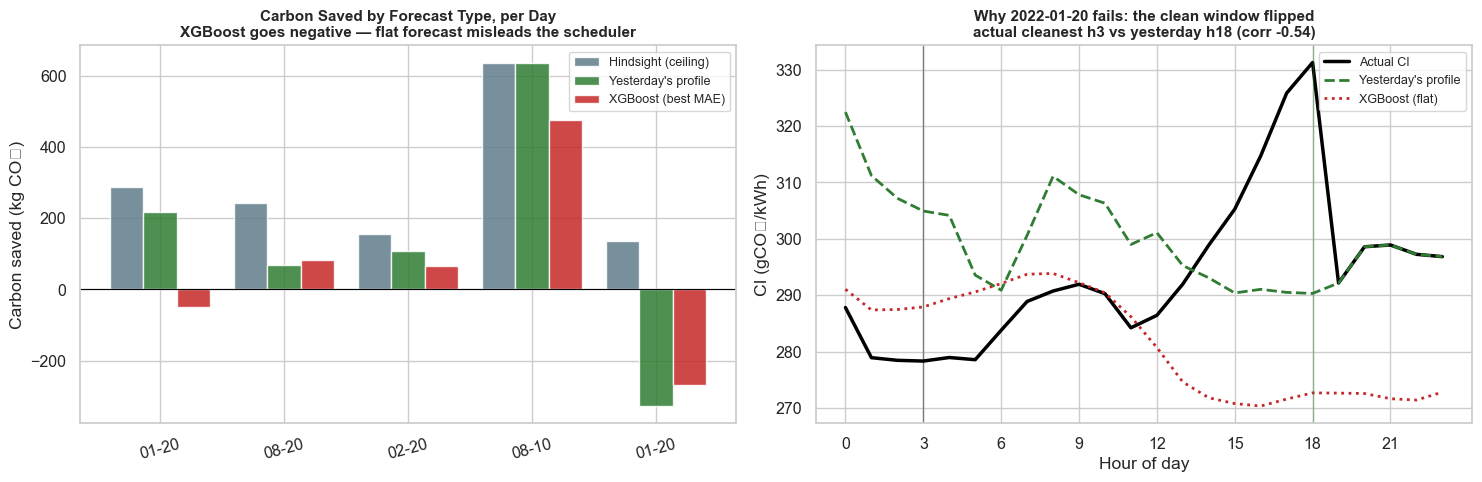

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: saved by forecast type per day
x = np.arange(len(DAYS)); w = 0.27
axes[0].bar(x-w, shape['hindsight'], w, color=GREY,  label='Hindsight (ceiling)', alpha=0.85)
axes[0].bar(x,   shape['yesterday'], w, color=GREEN, label="Yesterday's profile", alpha=0.85)
axes[0].bar(x+w, shape['xgboost'],   w, color=RED,   label='XGBoost (best MAE)', alpha=0.85)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels([d[5:] for d in DAYS], rotation=15)
axes[0].set_ylabel('Carbon saved (kg CO₂)')
axes[0].set_title('Carbon Saved by Forecast Type, per Day\nXGBoost goes negative — flat forecast misleads the scheduler',
                  fontweight='bold', fontsize=11)
axes[0].legend(fontsize=9)

# Right: the 2022-01-20 window flip
day='2022-01-20'; _,_,ca = day_arrays(day)
yd = yesterday_profile(day); xb = xgb_day_forecast(day)
axes[1].plot(range(24), ca, color='black', lw=2.5, label='Actual CI')
axes[1].plot(range(24), yd, color=GREEN, lw=2, ls='--', label="Yesterday's profile")
axes[1].plot(range(24), xb, color=RED, lw=2, ls=':', label='XGBoost (flat)')
axes[1].axvline(ca.argmin(), color='black', alpha=0.4, lw=1)
axes[1].axvline(yd.argmin(), color=GREEN, alpha=0.4, lw=1)
axes[1].set_xlabel('Hour of day'); axes[1].set_ylabel('CI (gCO₂/kWh)')
axes[1].set_title(f'Why {day} fails: the clean window flipped\n'
                  f'actual cleanest h{ca.argmin()} vs yesterday h{yd.argmin()} (corr {np.corrcoef(ca,yd)[0,1]:.2f})',
                  fontweight='bold', fontsize=11)
axes[1].legend(fontsize=9); axes[1].set_xticks(range(0,24,3))
plt.tight_layout(); plt.savefig(EDA_DIR/'opt_forecast_shape.png', dpi=150, bbox_inches='tight'); plt.show()

### The connection to Phase 2

The catastrophic failure on **2022-01-20** is not a bug — it is the **"moving clean window"** finding from Phase 2 made concrete. That day the actual cleanest hour was 03:00, but the previous day's was 18:00 — a correlation of **−0.54** (anti-correlated). When the clean window flips overnight, *any* day-ahead forecast misleads the scheduler, and committing energy to the forecast-clean hours actively increases carbon.

**This is the core real-world challenge:** the opportunity is real (hindsight ceiling), but capturing it depends on forecasting a target that, on the TVA grid, moves unpredictably. It explains why realistic savings (~51 tCO₂/yr) capture only ~48% of the capacity-aware ceiling (~106 tCO₂/yr).

---
## 5 · Conclusion

In [8]:
print('═'*64)
print('  PHASE 4 — PRESCRIPTIVE OPTIMISATION: CONCLUSION')
print('═'*64)
print('\n  Schedulers built:')
print('    • Greedy heuristic  — per-job, powers the dashboard widget')
print('    • LP (MIP)          — fleet-optimal under node/deadline constraints')
print('    • Load-shift LP     — capacity-aware fleet energy redistribution')
print('\n  Savings hierarchy (honest):')
print(f'    • Unconstrained potential   : {unconstrained_annual:.0f} tCO₂/yr  (ignores capacity)')
print(f'    • Capacity-aware ceiling    : {ceiling_annual:.0f} tCO₂/yr  (perfect forecast)')
print(f'    • Realistic forecast-driven : {forecast_annual:.0f} tCO₂/yr  (~48% of ceiling)')
print('\n  Key finding — forecast SHAPE beats point accuracy:')
print('    • XGBoost (best Phase-3 MAE) produces flat multi-step forecasts')
print('      that fail for scheduling (can go negative)')
print("    • Yesterday's-profile preserves daily shape, captures ~48% of ceiling")
print('    • The metric that selects a forecaster (MAE) is NOT aligned with')
print('      the scheduling objective (ordering of clean hours)')
print('\n  Ties to Phase 2: the moving clean window makes day-ahead CI shape')
print('  hard to predict — the central real-world challenge, honestly quantified.')
print('═'*64)

════════════════════════════════════════════════════════════════
  PHASE 4 — PRESCRIPTIVE OPTIMISATION: CONCLUSION
════════════════════════════════════════════════════════════════

  Schedulers built:
    • Greedy heuristic  — per-job, powers the dashboard widget
    • LP (MIP)          — fleet-optimal under node/deadline constraints
    • Load-shift LP     — capacity-aware fleet energy redistribution

  Savings hierarchy (honest):
    • Unconstrained potential   : 293 tCO₂/yr  (ignores capacity)
    • Capacity-aware ceiling    : 106 tCO₂/yr  (perfect forecast)
    • Realistic forecast-driven : 51 tCO₂/yr  (~48% of ceiling)

  Key finding — forecast SHAPE beats point accuracy:
    • XGBoost (best Phase-3 MAE) produces flat multi-step forecasts
      that fail for scheduling (can go negative)
    • Yesterday's-profile preserves daily shape, captures ~48% of ceiling
    • The metric that selects a forecaster (MAE) is NOT aligned with
      the scheduling objective (ordering of clean hour